COVID-19 GLOBAL DATA ANALYSIS

An exploratory data analysis of the Johns Hopkins COVID-19 dataset covering January 2020 to March 2023.

This project looks at how the pandemic unfolded across India, the US, and the United Kingdom — tracking case counts, daily new infections, death rates, and monthly trends over time.

Dataset used: John Hopkins CSSE time Series Data
Tools used: Python, Pandas, Matplotlib, Seaborn
Key questions asked:

1) How did case counts grow over time across countries?
2) Which countries were hit hardest overall?
3) How did the death rate change as the pandemic progressed?
4) What did each country's wave pattern look like?

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('time_series_covid19_confirmed_global.csv')

print(df.shape)
df.head()

(289, 1147)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [13]:
print(df.columns.tolist())

['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/20', '4/14/20', '4/15/20', '4/16/20', '4/17/20', '4/18/20', '4/19/2

In [14]:
df_melted = df.melt(
    id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
    var_name='date',
    value_name='confirmed_cases'
)

df_melted['date'] = pd.to_datetime(df_melted['date'])

print(df_melted.shape)
df_melted.head()

C:\Users\Akshaya\AppData\Local\Temp\ipykernel_30776\3330713518.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_melted['date'] = pd.to_datetime(df_melted['date'])


(330327, 6)


,Province/State,Country/Region,Lat,Long,date,confirmed_cases
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0
1,NaN,Albania,41.15330,20.168300,2020-01-22,0
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0


In [15]:
print(df.shape)

(289, 1147)


In [16]:
df_country = df_melted.groupby(
    ['Country/Region', 'date']
)['confirmed_cases'].sum().reset_index()

df_country.head(10)

,Country/Region,date,confirmed_cases
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0
5,Afghanistan,2020-01-27,0
6,Afghanistan,2020-01-28,0
7,Afghanistan,2020-01-29,0
8,Afghanistan,2020-01-30,0
9,Afghanistan,2020-01-31,0


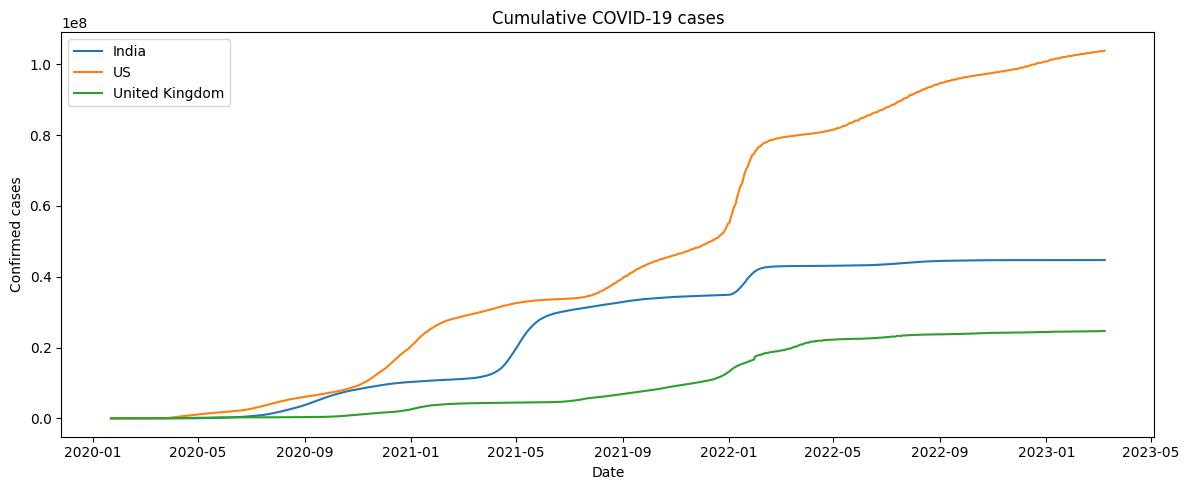

In [17]:
countries = ['India', 'US', 'United Kingdom']

fig, ax = plt.subplots(figsize=(12, 5))

for country in countries:
    data = df_country[df_country['Country/Region'] == country]
    ax.plot(data['date'], data['confirmed_cases'], label=country)

ax.set_title('Cumulative COVID-19 cases')
ax.set_xlabel('Date')
ax.set_ylabel('Confirmed cases')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#This chart shows the total number of confirmed COVID-19 cases accumulated over time in India, the US, and the United Kingdom. 
#Since the numbers keep increasing, the lines only ever go upward.


In [18]:
df_country['daily_cases'] = df_country.groupby(
    'Country/Region'
)['confirmed_cases'].diff().fillna(0)

df_country[df_country['Country/Region'] == 'India'].tail(10)

,Country/Region,date,confirmed_cases,daily_cases
92573,India,2023-02-28,44687837,240.0
92574,India,2023-03-01,44688105,268.0
92575,India,2023-03-02,44688388,283.0
92576,India,2023-03-03,44688722,334.0
92577,India,2023-03-04,44689046,324.0
92578,India,2023-03-05,44689327,281.0
92579,India,2023-03-06,44689593,266.0
92580,India,2023-03-07,44689919,326.0
92581,India,2023-03-08,44690298,379.0
92582,India,2023-03-09,44690738,440.0


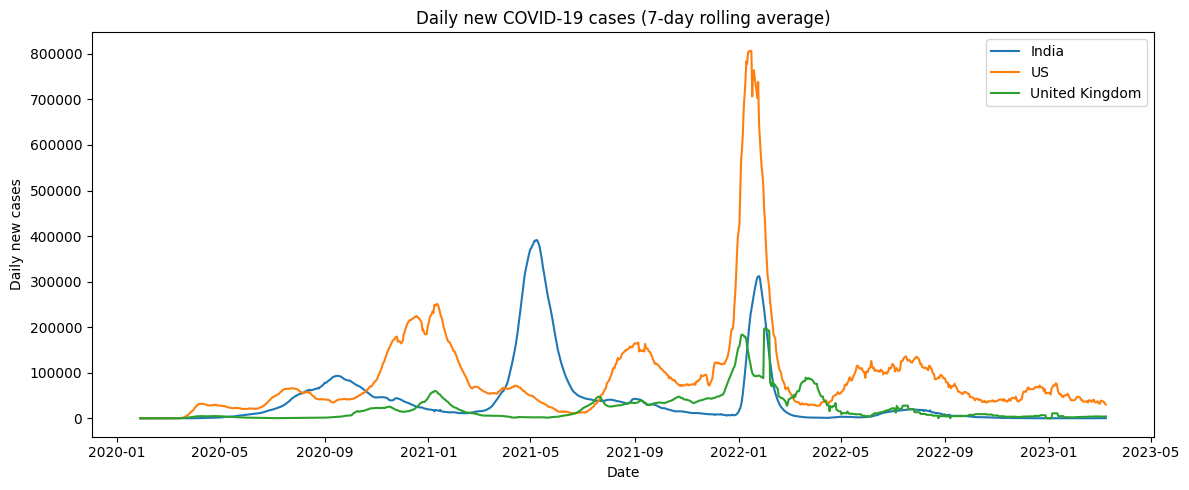

In [20]:
df_country['rolling_avg'] = df_country.groupby('Country/Region')['daily_cases'].transform(
    lambda x: x.rolling(7).mean()
)

countries = ['India', 'US', 'United Kingdom']

fig, ax = plt.subplots(figsize=(12, 5))

for country in countries:
    data = df_country[df_country['Country/Region'] == country]
    ax.plot(data['date'], data['rolling_avg'], label=country)

ax.set_title('Daily new COVID-19 cases (7-day rolling average)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily new cases')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#As for India, 3 distinct waves are visible- a moderate first wave in 2020, the Delta wave peaking at ~400,000 cases per day mid 2021, 
#and a sharp but brief Omicron spike in early 2022. The US shows more frequent waves, reflecting repeated surges throughout the pandemic. 
#The Omicron wave in January 2022 produced the single highest daily case count across all three countries.

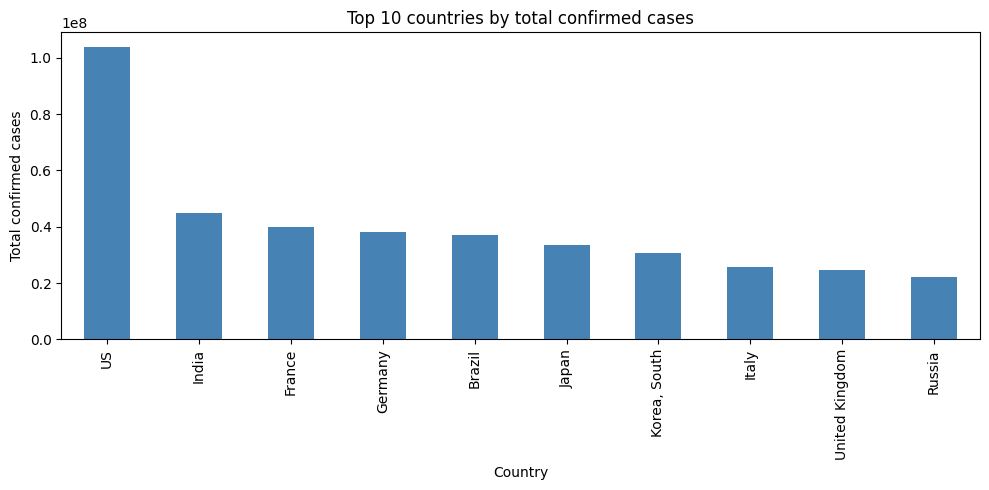

In [22]:
top10 = df_country.groupby('Country/Region')['confirmed_cases'].max().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 countries by total confirmed cases')
ax.set_xlabel('Country')
ax.set_ylabel('Total confirmed cases')
plt.tight_layout()
plt.show()

In [ ]:
#This bar chart ranks the 10 countries with the highest total confirmed COVID-19 cases across the entire pandemic. 
#Each bar represents the maximum cumulative case count reached by that country.
#The US leads by a significant margin at over 100 million cases, followed by India. 

In [23]:
url_deaths = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv'

df_deaths = pd.read_csv(url_deaths)

In [31]:
df_deaths_melted = df_deaths.melt(
    id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
    var_name='date',
    value_name='deaths'
)
df_deaths_melted['date'] = pd.to_datetime(df_deaths_melted['date'], format='%m/%d/%y')

df_deaths_country = df_deaths_melted.groupby(
    ['Country/Region', 'date']
)['deaths'].sum().reset_index()

In [25]:
df_merged = df_country.merge(df_deaths_country, on=['Country/Region', 'date'])

In [26]:
df_merged['death_rate'] = df_merged['deaths'] / df_merged['confirmed_cases'] * 100
df_merged['death_rate'] = df_merged['death_rate'].fillna(0)

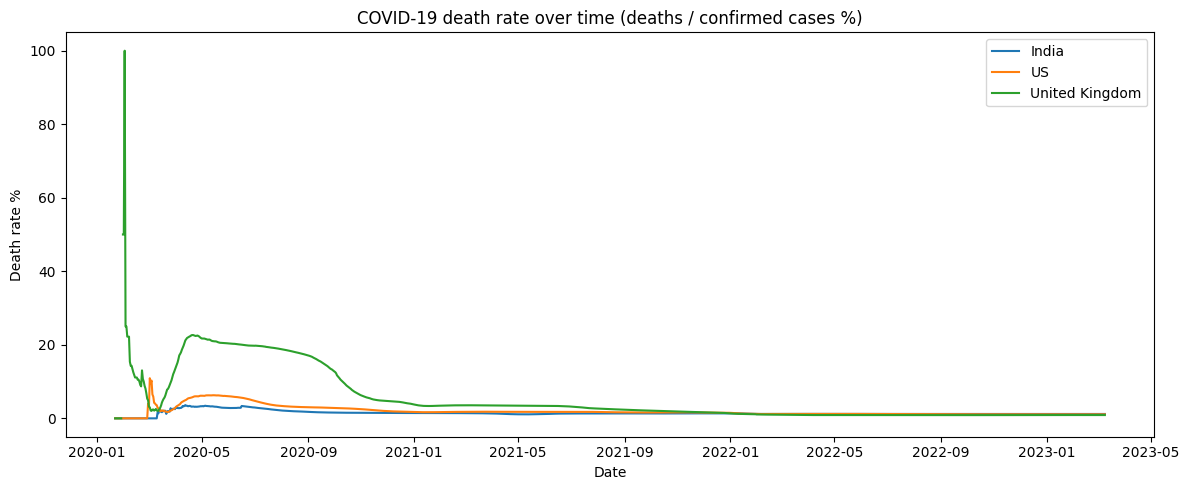

In [27]:
countries = ['India', 'US', 'United Kingdom']

fig, ax = plt.subplots(figsize=(12, 5))

for country in countries:
    data = df_merged[df_merged['Country/Region'] == country]
    ax.plot(data['date'], data['death_rate'], label=country)

ax.set_title('COVID-19 death rate over time (deaths / confirmed cases %)')
ax.set_xlabel('Date')
ax.set_ylabel('Death rate %')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#This chart shows the case fatality rate — the percentage of confirmed cases that resulted in death
#All three countries drop by 2022 as vaccination scaled up.

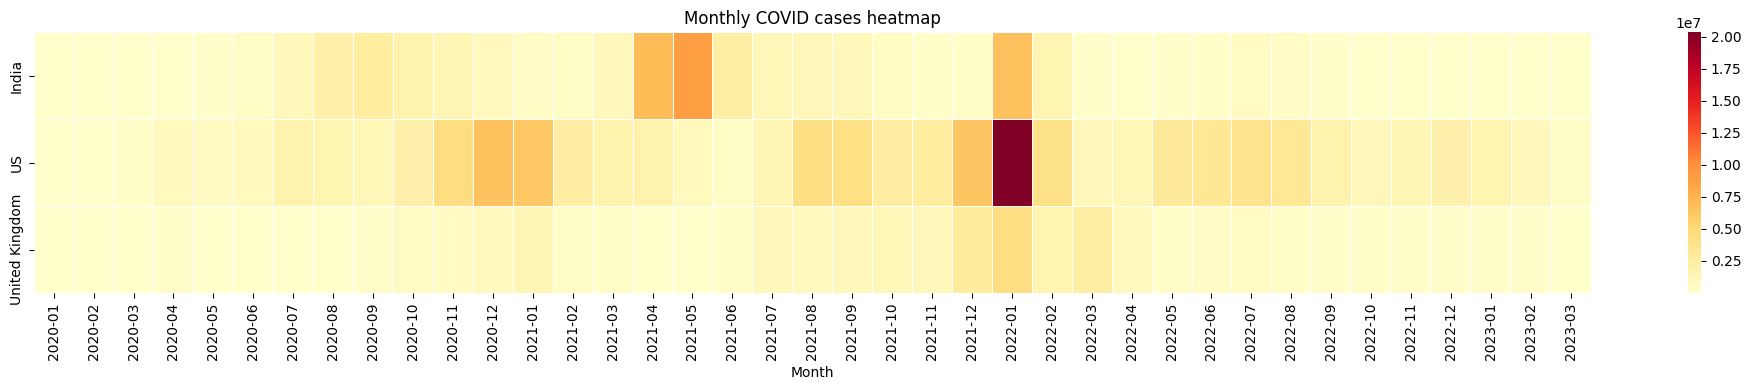

In [28]:
india_monthly = df_country[df_country['Country/Region'] == 'India'].copy()
india_monthly['month'] = india_monthly['date'].dt.to_period('M')
india_monthly = india_monthly.groupby('month')['daily_cases'].sum().reset_index()
india_monthly['month'] = india_monthly['month'].astype(str)

countries_list = ['India', 'US', 'United Kingdom']
monthly_data = []

for country in countries_list:
    temp = df_country[df_country['Country/Region'] == country].copy()
    temp['month'] = temp['date'].dt.to_period('M').astype(str)
    temp = temp.groupby('month')['daily_cases'].sum()
    temp.name = country
    monthly_data.append(temp)

heatmap_df = pd.DataFrame(monthly_data)

plt.figure(figsize=(20, 4))
sns.heatmap(heatmap_df, cmap='YlOrRd', linewidths=0.5)
plt.title('Monthly COVID cases heatmap')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [ ]:
#Each cell shows total new cases for that country in that month. 
#The darkest cell — US January 2022 — is the Omicron wave, the single most infectious month of the entire pandemic
#India's orange block in April–May 2021 is the Delta wave. 
#The right half of the chart is mostly pale yellow across all three countries, showing the clear decline after 2022.

In [32]:
india = df_merged[df_merged['Country/Region'] == 'India'].copy()

# Define the three waves roughly
wave1 = india[(india['date'] >= '2020-03-01') & (india['date'] <= '2020-12-31')]
wave2 = india[(india['date'] >= '2021-03-01') & (india['date'] <= '2021-08-31')]
wave3 = india[(india['date'] >= '2022-01-01') & (india['date'] <= '2022-04-30')]

print("Wave 1 peak daily cases:", int(wave1['daily_cases'].max()))
print("Wave 2 peak daily cases:", int(wave2['daily_cases'].max()))
print("Wave 3 peak daily cases:", int(wave3['daily_cases'].max()))

print("\nWave 1 total deaths:", int(wave1['deaths'].max() - wave1['deaths'].min()))
print("Wave 2 total deaths:", int(wave2['deaths'].max() - wave2['deaths'].min()))
print("Wave 3 total deaths:", int(wave3['deaths'].max() - wave3['deaths'].min()))





Wave 1 peak daily cases: 97894
Wave 2 peak daily cases: 414188
Wave 3 peak daily cases: 347254

Wave 1 total deaths: 148994
Wave 2 total deaths: 281772
Wave 3 total deaths: 42073


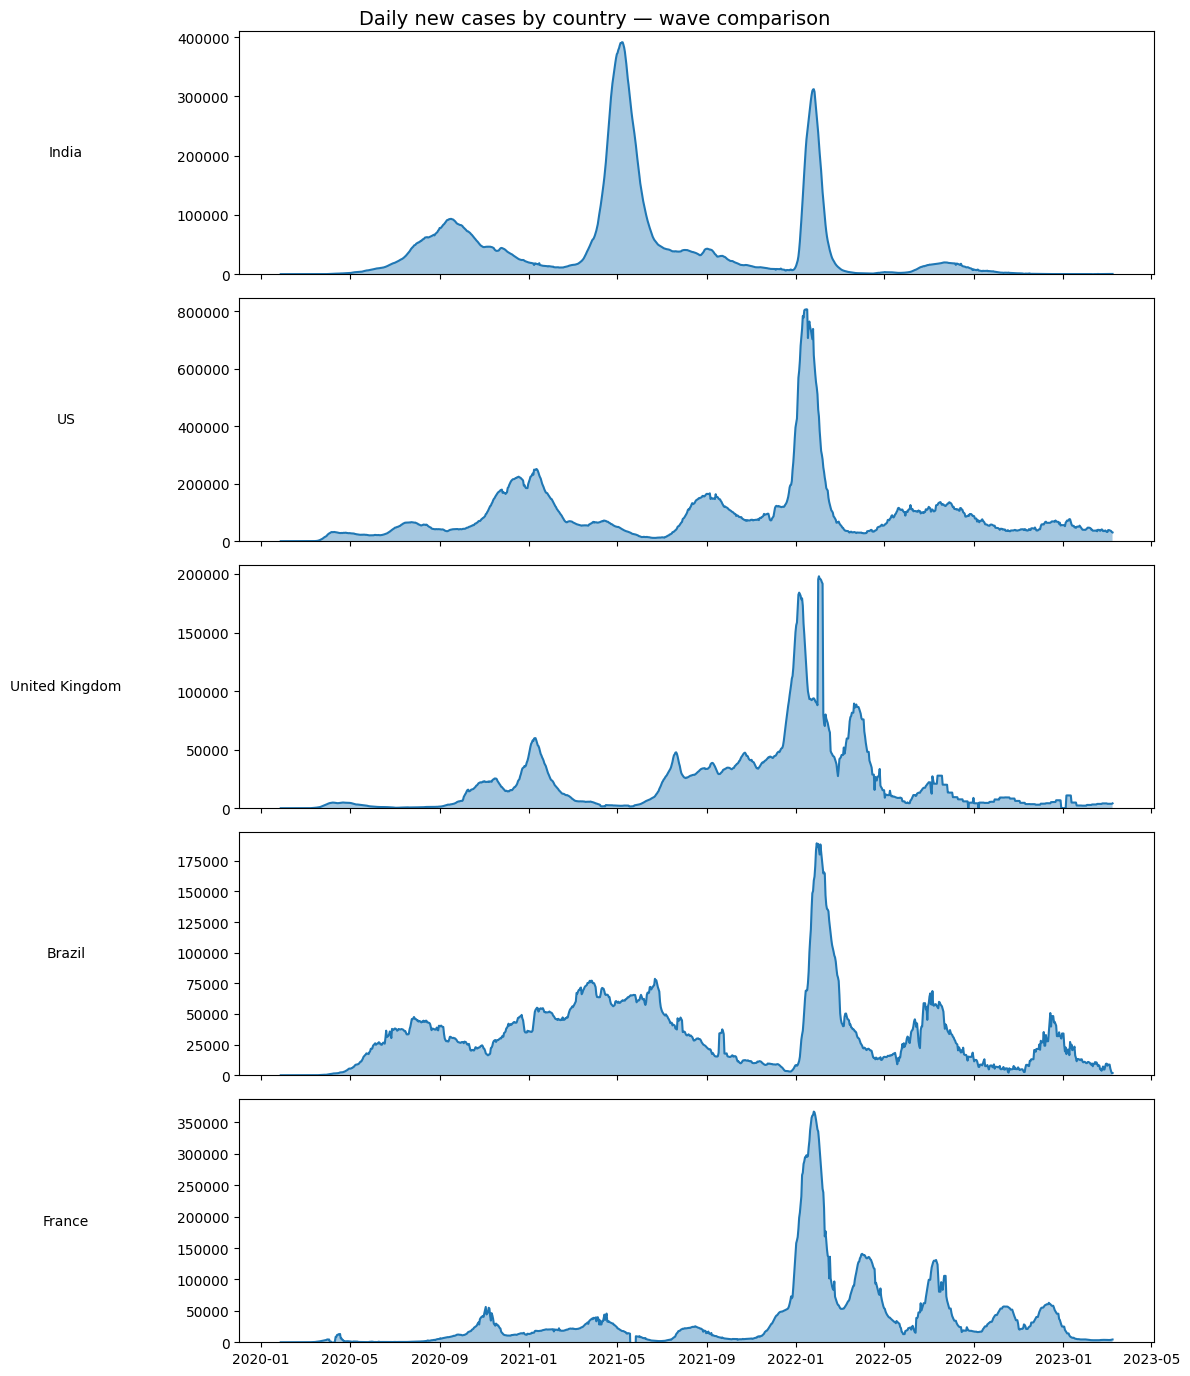

In [30]:
countries = ['India', 'US', 'United Kingdom', 'Brazil', 'France']

fig, axes = plt.subplots(len(countries), 1, figsize=(12, 14), sharex=True)

for i, country in enumerate(countries):
    data = df_country[df_country['Country/Region'] == country].copy()
    axes[i].fill_between(data['date'], data['rolling_avg'], alpha=0.4)
    axes[i].plot(data['date'], data['rolling_avg'])
    axes[i].set_ylabel(country, rotation=0, labelpad=80, va='center')
    axes[i].set_ylim(bottom=0)

fig.suptitle('Daily new cases by country — wave comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#One panel per country showing the shape of each wave. Every country has a distinct pandemic pattern — India had sharp concentrated spikes 
#the US had prolonged overlapping waves with no clear recovery between them.